# 02. Analisis exploratorio de las etiquetas

Este cuaderno estudia las etiquetas del conjunto de datos. Analiza la magnitud del dano como
variable cuantitativa, describe las variables categoricas, examina las relaciones entre ellas y
evalua dos riesgos que condicionan el diseno de cualquier modelo posterior: la agrupacion de
fotografias por campo y el desplazamiento de las distribuciones entre temporadas. Parte de los
metadatos guardados por el cuaderno `01_adquisicion_datos` y no vuelve a leer los CSV originales.

## Entorno

In [1]:
import sys
from pathlib import Path


def raiz_proyecto():
    for candidato in [Path.cwd(), *Path.cwd().parents]:
        if (candidato / "src").is_dir():
            return candidato
    raise RuntimeError("No se encontro la raiz del proyecto")


RAIZ = raiz_proyecto()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

%matplotlib inline
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

from src import carga, graficos, limpieza, tablas
from src.config import ORDEN_DANOS, ORDEN_ETAPAS, TEMPORADAS, TIPOS_DANO

graficos.aplicar_estilo()

train = carga.cargar_metadatos("train")
test = carga.cargar_metadatos("test")
print(f"train: {train.shape[0]} registros, {train.shape[1]} columnas")
print(f"test:  {test.shape[0]} registros, {test.shape[1]} columnas")

train: 26068 registros, 20 columnas
test:  8663 registros, 19 columnas


## Estructura del conjunto

El diccionario de datos distingue las variables originales de la competencia (identificador,
archivo, etapa, dano, magnitud, temporada) de las derivadas durante la preparacion (productor,
campo, cultivo, sitio, tipo de captura, indicadores de calidad). El conteo por escala de medicion
resume que tipo de variable predomina.

In [2]:
diccionario = carga.diccionario_datos(train)[["variable", "tipo", "escala", "nulos", "unicos"]]
diccionario

,variable,tipo,escala,nulos,unicos
0,id,str,texto,0,26068
1,archivo,str,texto,0,26068
2,etapa,category,ordinal,0,4
3,dano,category,nominal,0,8
4,magnitud,int64,cuantitativa,0,11
5,temporada,category,ordinal,0,4
6,particion,str,texto,0,1
7,formato_nombre,category,nominal,0,3
8,id_productor,str,texto,2712,221
9,id_campo,str,texto,2712,3051


In [3]:
diccionario["escala"].value_counts()

escala
texto           8
binaria         6
ordinal         3
nominal         2
cuantitativa    1
Name: count, dtype: int64

## Variable objetivo: magnitud del dano

La magnitud es un porcentaje de perdida discreto, acotado entre cero y cien y registrado en pasos
de diez. Se describe su distribucion, su fuerte concentracion en cero, y por que el criterio
clasico de valores atipicos no es apropiado para esta variable.

In [4]:
tablas.resumen_numerico(train, ["magnitud"])

,variable,conteo,faltantes,media,desviacion,minimo,q1,mediana,q3,maximo,asimetria,curtosis
0,magnitud,26068,0,7.0961,18.6132,0,0.0,0.0,0.0,100,2.9107,8.0279


In [5]:
print(f"proporcion con magnitud 0:   {(train['magnitud'] == 0).mean():.4f}")
print(f"proporcion con magnitud 100: {(train['magnitud'] == 100).mean():.4f}")

proporcion con magnitud 0:   0.8270
proporcion con magnitud 100: 0.0017


In [6]:
tablas.tabla_frecuencia(train, "magnitud")

,magnitud,frecuencia,proporcion,proporcion_acumulada
0,0,21558,0.826991,0.826991
1,10,729,0.027965,0.854956
2,20,690,0.026469,0.881426
3,30,727,0.027889,0.909314
4,40,696,0.026699,0.936014
5,50,445,0.017071,0.953084
6,60,388,0.014884,0.967968
7,70,199,0.007634,0.975602
8,80,291,0.011163,0.986765
9,90,300,0.011508,0.998274


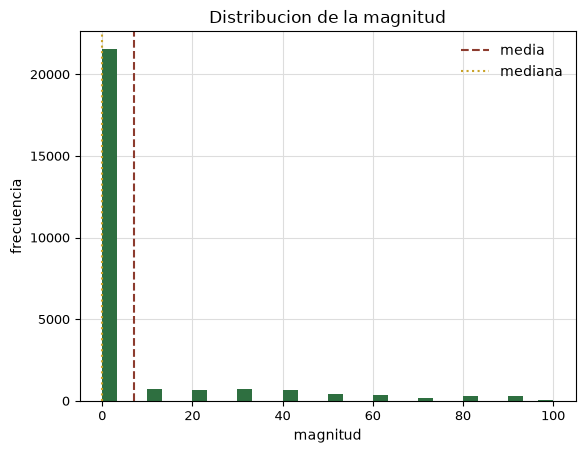

In [7]:
_ = graficos.histograma(
    train["magnitud"], "Distribucion de la magnitud", "magnitud", nombre_archivo="02_histograma_magnitud"
)

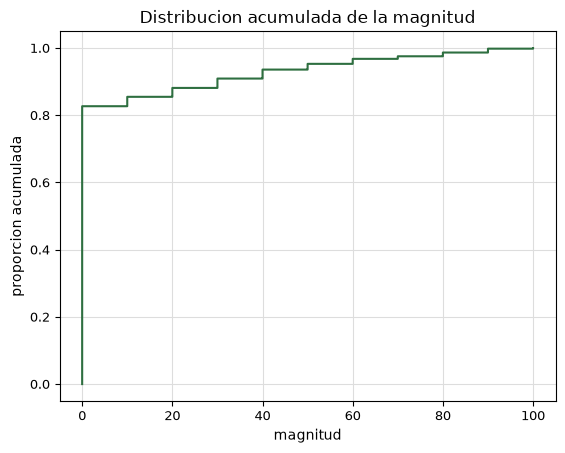

In [8]:
_ = graficos.ecdf(
    train["magnitud"], "Distribucion acumulada de la magnitud", "magnitud", nombre_archivo="02_ecdf_magnitud"
)

In [9]:
tablas.resumen_atipicos(train, ["magnitud"])

,variable,limite_inferior,limite_superior,atipicos,proporcion
0,magnitud,0.0,0.0,4510,0.173


El criterio del rango intercuartilico no es apropiado aqui. Como la magnitud esta fuertemente
concentrada en cero, el primer y el tercer cuartil valen cero, el rango intercuartilico es nulo y
el criterio marca como atipico cualquier valor positivo. Pero los valores positivos son
precisamente el fenomeno de interes, de modo que aplicar esa regla contradiria el proposito del
analisis. No se eliminan esos registros.

## La magnitud como variable condicionada al diagnostico de sequia

La regla estructural y el resumen de la magnitud por tipo de dano muestran que la magnitud toma
valores positivos casi exclusivamente cuando el dano declarado es sequia. Esto es una regla de
construccion del conjunto, no una correlacion estadistica, y separa dos preguntas distintas: si la
fotografia corresponde a un caso de sequia, y en caso afirmativo, que tan severa es.

In [10]:
limpieza.regla_estructural(train)

,caso,registros,porcentaje
0,magnitud positiva con dano distinto de sequia,0,0.000
1,sequia declarada con magnitud cero,6,0.023
2,crecimiento sano con magnitud positiva,0,0.000


In [11]:
resumen_por_dano = train.groupby("dano", observed=True)["magnitud"].agg(
    tamano="size", media="mean", maximo="max"
)
resumen_por_dano["descripcion"] = resumen_por_dano.index.map(TIPOS_DANO)
resumen_por_dano

,tamano,media,maximo,descripcion
dano,,,,
G,11623,0.000000,0,Crecimiento sano
DR,4516,40.961027,100,Sequia
DS,115,0.000000,0,Enfermedad
FD,13,0.000000,0,Inundacion
ND,272,0.000000,0,Deficiencia de nutrientes
PS,254,0.000000,0,Plaga
WD,9238,0.000000,0,Maleza
WN,37,0.000000,0,Viento


La magnitud media es practicamente cero en todos los tipos de dano salvo sequia, y solo la sequia
alcanza magnitudes altas. El problema util no es estimar la magnitud sobre el conjunto completo,
sino sobre el subconjunto diagnosticado con sequia.

## Consecuencia sobre el conjunto de prueba

El archivo de prueba distribuye el tipo de dano junto con las imagenes. Si la regla anterior se
sostiene, los registros de prueba con un tipo de dano distinto de sequia tienen una respuesta de
magnitud conocida de antemano, igual a cero, y solo los registros de sequia exigen estimar un
valor.

In [12]:
no_sequia_test = int((test["dano"] != "DR").sum())
sequia_test = int((test["dano"] == "DR").sum())
print(f"registros de prueba con dano distinto de sequia (magnitud 0 conocida): {no_sequia_test}")
print(f"registros de prueba con sequia (exigen estimar): {sequia_test}")
print(f"proporcion determinada de antemano: {no_sequia_test / len(test):.4f}")

registros de prueba con dano distinto de sequia (magnitud 0 conocida): 7160
registros de prueba con sequia (exigen estimar): 1503
proporcion determinada de antemano: 0.8265


In [13]:
tablas.comparar_distribuciones_categoricas(train, test, "dano")

,dano,train,test,diferencia
0,G,0.445872,0.446612,-0.000740
1,WD,0.354381,0.354958,-0.000577
2,DR,0.173239,0.173496,-0.000257
3,ND,0.010434,0.010158,0.000276
4,PS,0.009744,0.009350,0.000394
5,DS,0.004412,0.003809,0.000602
6,WN,0.001419,0.001270,0.000150
7,FD,0.000499,0.000346,0.000152


Una porcion considerable del conjunto de prueba queda determinada sin mirar la imagen. El
planteamiento util del problema es estimar la magnitud sobre el subconjunto diagnosticado con
sequia y no sobre el conjunto completo.

## Distribucion de la magnitud dentro del subconjunto de sequia

Al aislar las filas cuyo dano es sequia, la magnitud deja de estar dominada por el cero y su forma
cambia. El diagrama de caja por temporada revela si la severidad tipica difiere entre temporadas,
que es la evidencia mas directa del fenomeno de perdida de desempeno que motiva el desafio.

In [14]:
sequia = train[train["dano"] == "DR"].copy()
print(f"registros de sequia en entrenamiento: {len(sequia)}")
tablas.resumen_numerico(sequia, ["magnitud"])

registros de sequia en entrenamiento: 4516


,variable,conteo,faltantes,media,desviacion,minimo,q1,mediana,q3,maximo,asimetria,curtosis
0,magnitud,4516,0,40.961,24.7541,0,20.0,40.0,60.0,100,0.5912,-0.6491


In [15]:
tablas.tabla_frecuencia(sequia, "magnitud")

,magnitud,frecuencia,proporcion,proporcion_acumulada
0,0,6,0.001329,0.001329
1,10,729,0.161426,0.162755
2,20,690,0.152790,0.315545
3,30,727,0.160983,0.476528
4,40,696,0.154119,0.630647
5,50,445,0.098539,0.729185
6,60,388,0.085917,0.815102
7,70,199,0.044066,0.859167
8,80,291,0.064438,0.923605
9,90,300,0.066430,0.990035


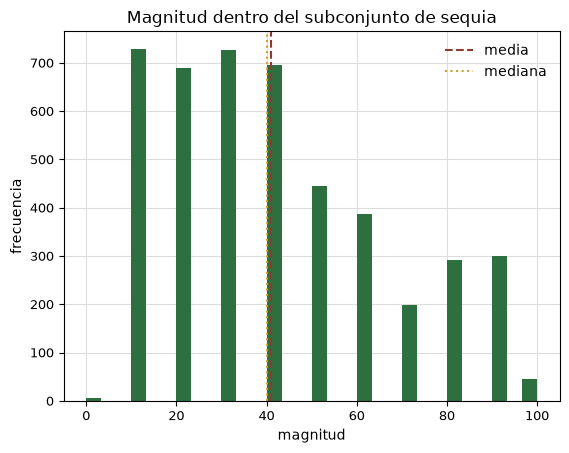

In [16]:
_ = graficos.histograma(
    sequia["magnitud"], "Magnitud dentro del subconjunto de sequia", "magnitud",
    nombre_archivo="02_histograma_magnitud_sequia",
)

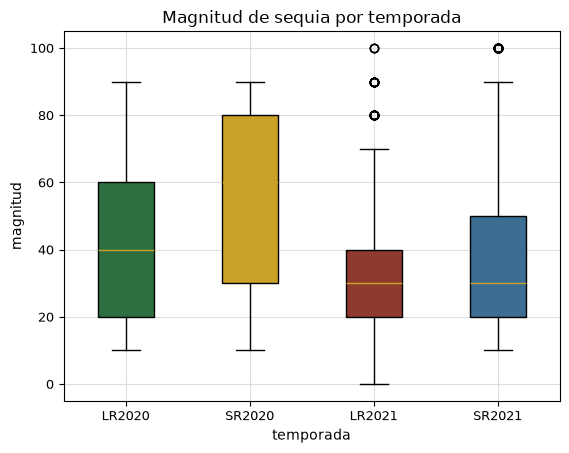

In [17]:
_ = graficos.caja_por_categoria(
    sequia, "temporada", "magnitud", "Magnitud de sequia por temporada",
    nombre_archivo="02_caja_magnitud_sequia_temporada",
)

In [18]:
tablas.resumen_por_grupo(sequia, "temporada", "magnitud")

,temporada,tamano,media,desviacion,minimo,q1,mediana,q3,maximo,prop_cero
0,LR2020,391,43.145780,24.921965,10,20.0,40.0,60.0,90,0.000000
1,SR2020,1146,53.516579,28.824544,10,30.0,60.0,80.0,90,0.000000
2,LR2021,1413,34.501062,18.236199,0,20.0,30.0,40.0,100,0.004246
3,SR2021,1566,37.056194,23.141861,10,20.0,30.0,50.0,100,0.000000


La severidad tipica de la sequia cambia de forma marcada entre temporadas. Un modelo que aprende
la relacion entre la imagen y la magnitud en unas temporadas encuentra en otra una distribucion de
severidad distinta, lo que explica en parte la caida de desempeno entre temporadas.

## Variables categoricas

Se describen las tres variables categoricas centrales: tipo de dano, etapa de crecimiento y
temporada. Las temporadas se nombran segun el regimen de lluvias de Africa oriental: LR para
lluvias largas y SR para lluvias cortas, seguidas del ano.

In [19]:
frecuencia_dano = tablas.tabla_frecuencia(train, "dano")
frecuencia_dano["descripcion"] = frecuencia_dano["dano"].map(TIPOS_DANO)
frecuencia_dano

,dano,frecuencia,proporcion,proporcion_acumulada,descripcion
0,G,11623,0.445872,0.445872,Crecimiento sano
1,DR,4516,0.173239,0.619112,Sequia
2,DS,115,0.004412,0.623523,Enfermedad
3,FD,13,0.000499,0.624022,Inundacion
4,ND,272,0.010434,0.634456,Deficiencia de nutrientes
5,PS,254,0.009744,0.644200,Plaga
6,WD,9238,0.354381,0.998581,Maleza
7,WN,37,0.001419,1.000000,Viento


In [20]:
display(tablas.tabla_frecuencia(train, "etapa"))
display(tablas.tabla_frecuencia(train, "temporada"))

,etapa,frecuencia,proporcion,proporcion_acumulada
0,S,3225,0.123715,0.123715
1,V,10015,0.384188,0.507902
2,F,6164,0.236458,0.744361
3,M,6664,0.255639,1.000000


,temporada,frecuencia,proporcion,proporcion_acumulada
0,LR2020,2033,0.077988,0.077988
1,SR2020,6163,0.236420,0.314408
2,LR2021,7945,0.304780,0.619188
3,SR2021,9927,0.380812,1.000000


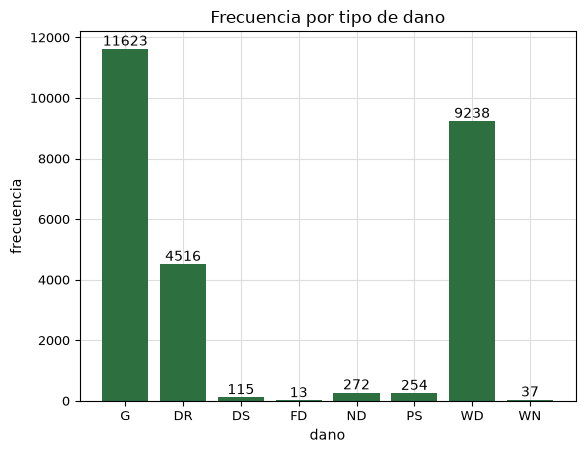

In [21]:
_ = graficos.barras_frecuencia(
    tablas.tabla_frecuencia(train, "dano"), "Frecuencia por tipo de dano", nombre_archivo="02_barras_dano"
)

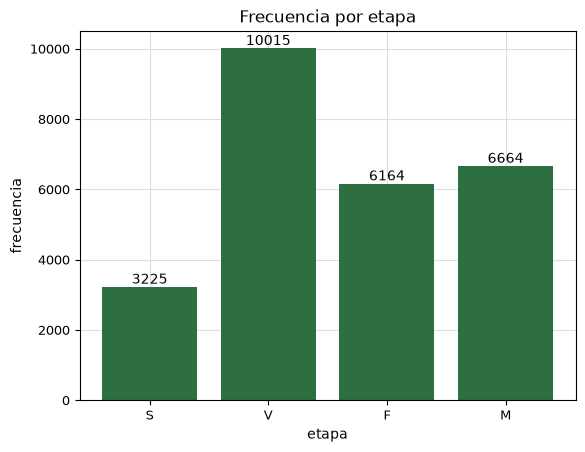

In [22]:
_ = graficos.barras_frecuencia(
    tablas.tabla_frecuencia(train, "etapa"), "Frecuencia por etapa", nombre_archivo="02_barras_etapa"
)

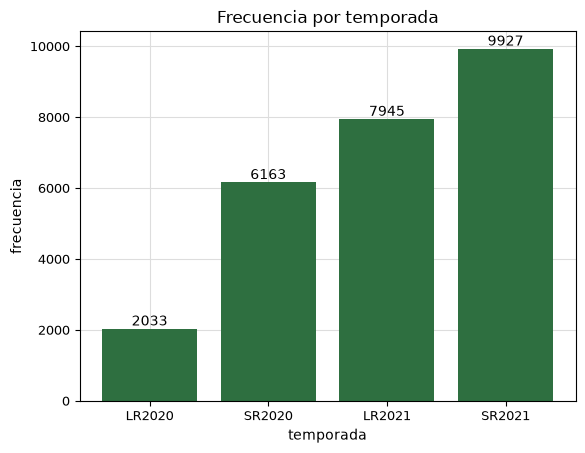

In [23]:
_ = graficos.barras_frecuencia(
    tablas.tabla_frecuencia(train, "temporada"), "Frecuencia por temporada", nombre_archivo="02_barras_temporada"
)

El crecimiento sano es la categoria mas frecuente y la sequia concentra la mayoria de los casos
con dano, coherente con que la sequia sea el motivo dominante de reclamacion.

## Tipo de captura

Cada tipo de captura tiene un proposito: la inicial es una referencia al comenzar el ciclo, el
seguimiento registra la evolucion, y el reclamo acompana un reporte de dano. Como cada uno tiene
una magnitud media distinta, un cambio en la composicion del tipo de captura entre temporadas
altera la distribucion de la magnitud aunque el terreno no cambie.

In [24]:
display(tablas.tabla_frecuencia(train, "tipo_captura"))
tablas.resumen_por_grupo(train, "tipo_captura", "magnitud")

,tipo_captura,frecuencia,proporcion,proporcion_acumulada
0,inicial,153,0.005869,0.005869
1,seguimiento,22744,0.872487,0.878357
2,reclamo,459,0.017608,0.895964
3,NaN,2712,0.104036,1.000000


,tipo_captura,tamano,media,desviacion,minimo,q1,mediana,q3,maximo,prop_cero
0,inicial,153,0.000000,0.000000,0,0.0,0.0,0.0,0,1.000000
1,seguimiento,22744,7.831076,19.428708,0,0.0,0.0,0.0,100,0.809752
2,reclamo,459,13.507625,23.225340,0,0.0,0.0,20.0,100,0.647059


In [25]:
display(tablas.tabla_contingencia(train, "temporada", "tipo_captura"))
tablas.tabla_contingencia(train, "temporada", "tipo_captura", normalizar="fila")

tipo_captura,inicial,seguimiento,reclamo
temporada,,,
LR2020,153,1880,0
SR2020,0,5347,0
LR2021,0,7945,0
SR2021,0,7572,459


tipo_captura,inicial,seguimiento,reclamo
temporada,,,
LR2020,0.075258,0.924742,0.000000
SR2020,0.000000,1.000000,0.000000
LR2021,0.000000,1.000000,0.000000
SR2021,0.000000,0.942846,0.057154


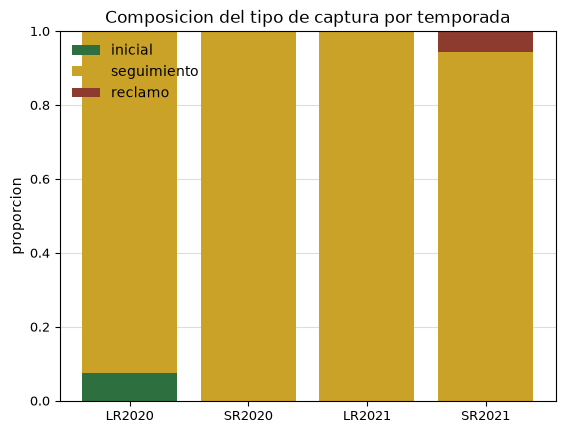

In [26]:
_ = graficos.barras_apiladas(
    tablas.tabla_contingencia(train, "temporada", "tipo_captura", normalizar="fila"),
    "Composicion del tipo de captura por temporada", "proporcion",
    nombre_archivo="02_apiladas_temporada_captura",
)

La composicion del tipo de captura no es homogenea entre temporadas. Como el reclamo concentra las
magnitudes altas, las temporadas con mayor proporcion de reclamos tienden a mostrar magnitudes
mas severas, un efecto de composicion que se suma a cualquier diferencia agronomica real.

## Cruce entre variables

Se cruzan la magnitud con el tipo de dano y con la etapa, y la etapa con el tipo de dano, para
entender el mecanismo que conecta la etapa del cultivo con la aparicion del dano.

,dano,tamano,media,desviacion,minimo,q1,mediana,q3,maximo,prop_cero
0,G,11623,0.000000,0.000000,0,0.0,0.0,0.0,0,1.000000
1,DR,4516,40.961027,24.754069,0,20.0,40.0,60.0,100,0.001329
2,DS,115,0.000000,0.000000,0,0.0,0.0,0.0,0,1.000000
3,FD,13,0.000000,0.000000,0,0.0,0.0,0.0,0,1.000000
4,ND,272,0.000000,0.000000,0,0.0,0.0,0.0,0,1.000000
5,PS,254,0.000000,0.000000,0,0.0,0.0,0.0,0,1.000000
6,WD,9238,0.000000,0.000000,0,0.0,0.0,0.0,0,1.000000
7,WN,37,0.000000,0.000000,0,0.0,0.0,0.0,0,1.000000


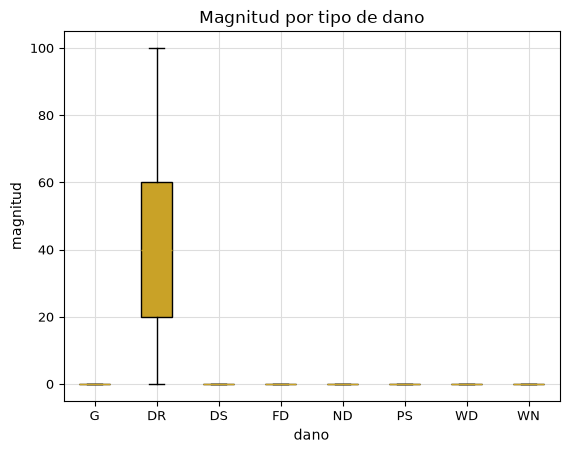

In [27]:
display(tablas.resumen_por_grupo(train, "dano", "magnitud"))
_ = graficos.caja_por_categoria(
    train, "dano", "magnitud", "Magnitud por tipo de dano", nombre_archivo="02_caja_magnitud_dano"
)

,etapa,tamano,media,desviacion,minimo,q1,mediana,q3,maximo,prop_cero
0,S,3225,0.285271,4.404260,0,0.0,0.0,0.0,100,0.993798
1,V,10015,1.530704,9.070185,0,0.0,0.0,0.0,100,0.959661
2,F,6164,4.600909,14.254805,0,0.0,0.0,0.0,100,0.862103
3,M,6664,21.063926,27.649846,0,0.0,0.0,40.0,100,0.514406


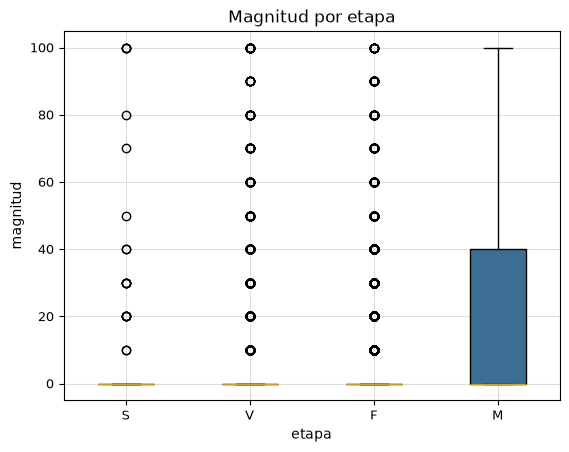

In [28]:
display(tablas.resumen_por_grupo(train, "etapa", "magnitud"))
_ = graficos.caja_por_categoria(
    train, "etapa", "magnitud", "Magnitud por etapa", nombre_archivo="02_caja_magnitud_etapa"
)

In [29]:
display(tablas.tabla_contingencia(train, "etapa", "dano"))
tablas.tabla_contingencia(train, "etapa", "dano", normalizar="fila")

dano,G,DR,DS,FD,ND,PS,WD,WN
etapa,,,,,,,,
S,2460,20,1,5,4,1,734,0
V,4409,406,8,6,43,163,4970,10
F,3095,852,48,1,42,62,2057,7
M,1659,3238,58,1,183,28,1477,20


dano,G,DR,DS,FD,ND,PS,WD,WN
etapa,,,,,,,,
S,0.762791,0.006202,0.000310,0.001550,0.001240,0.000310,0.227597,0.000000
V,0.440240,0.040539,0.000799,0.000599,0.004294,0.016276,0.496256,0.000999
F,0.502109,0.138222,0.007787,0.000162,0.006814,0.010058,0.333712,0.001136
M,0.248950,0.485894,0.008703,0.000150,0.027461,0.004202,0.221639,0.003001


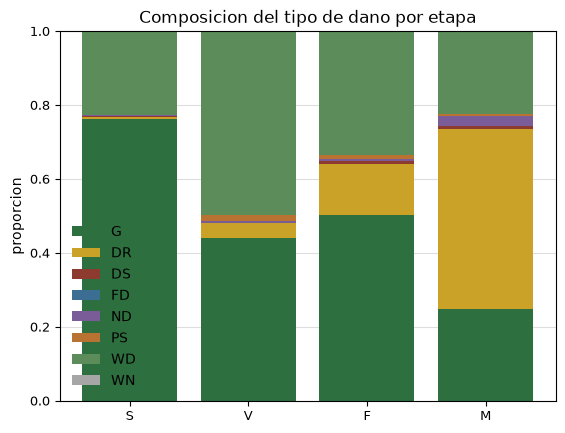

In [30]:
_ = graficos.barras_apiladas(
    tablas.tabla_contingencia(train, "etapa", "dano", normalizar="fila"),
    "Composicion del tipo de dano por etapa", "proporcion",
    nombre_archivo="02_apiladas_etapa_dano",
)

El dano por sequia se concentra en las etapas tardias del ciclo. Esto sugiere que la etapa no
actua como causa independiente sino como indicador del momento en que el dano se vuelve
observable en la fotografia.

## Composicion por temporada

Se examina como cambian entre temporadas la composicion del tipo de dano, la magnitud y la
composicion de la etapa.

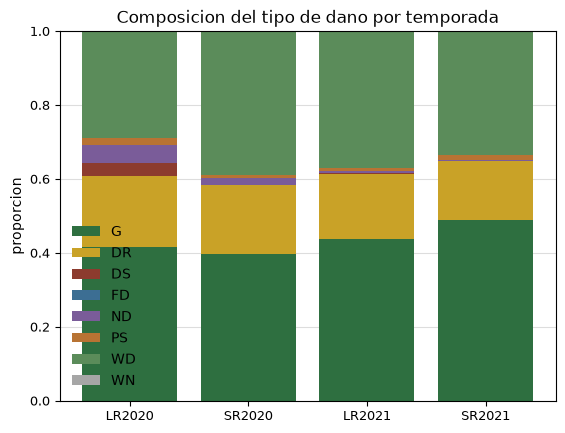

In [31]:
_ = graficos.barras_apiladas(
    tablas.tabla_contingencia(train, "temporada", "dano", normalizar="fila"),
    "Composicion del tipo de dano por temporada", "proporcion",
    nombre_archivo="02_apiladas_temporada_dano",
)

,temporada,tamano,media,desviacion,minimo,q1,mediana,q3,maximo,prop_cero
0,LR2020,2033,8.298082,20.211862,0,0.0,0.0,0.0,90,0.807673
1,SR2020,6163,9.951322,24.248475,0,0.0,0.0,0.0,90,0.814052
2,LR2021,7945,6.135935,15.270196,0,0.0,0.0,0.0,100,0.822907
3,SR2021,9927,5.845673,16.337155,0,0.0,0.0,0.0,100,0.842248


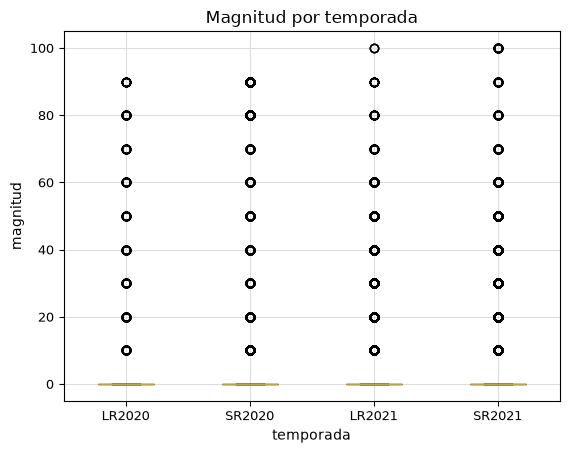

In [32]:
display(tablas.resumen_por_grupo(train, "temporada", "magnitud"))
_ = graficos.caja_por_categoria(
    train, "temporada", "magnitud", "Magnitud por temporada", nombre_archivo="02_caja_magnitud_temporada"
)

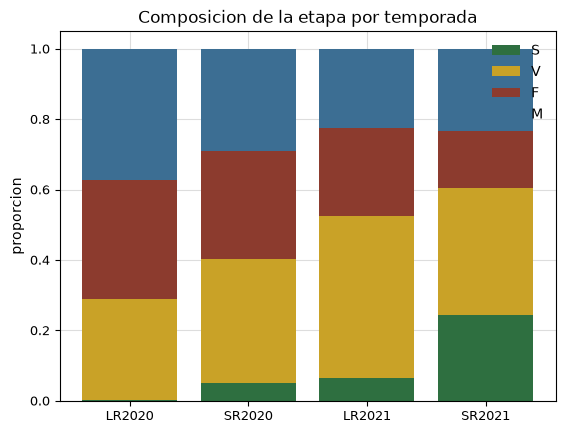

In [33]:
_ = graficos.barras_apiladas(
    tablas.tabla_contingencia(train, "temporada", "etapa", normalizar="fila"),
    "Composicion de la etapa por temporada", "proporcion",
    nombre_archivo="02_apiladas_temporada_etapa",
)

## Medidas de asociacion

La correlacion de Pearson no es adecuada porque las variables explicativas son categoricas y la
magnitud es discreta y acotada. Se usa la V de Cramer entre pares de variables categoricas y el
eta cuadrado para medir cuanta varianza de la magnitud explica cada variable categorica.

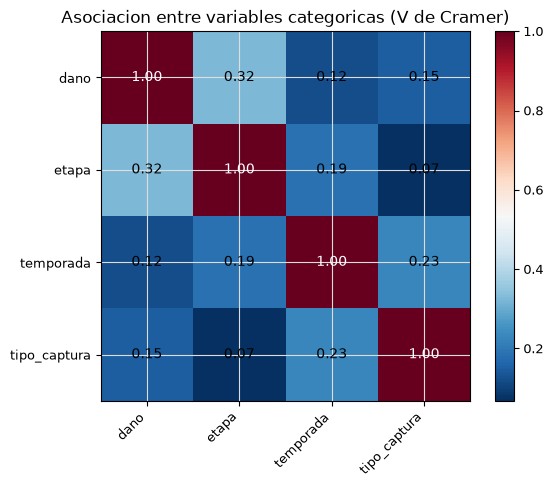

In [34]:
variables_categoricas = ["dano", "etapa", "temporada", "tipo_captura"]
_ = graficos.mapa_calor(
    tablas.matriz_v_cramer(train, variables_categoricas),
    "Asociacion entre variables categoricas (V de Cramer)", nombre_archivo="02_mapa_cramers",
)

In [35]:
tablas.tabla_eta_cuadrado(train, variables_categoricas, "magnitud")

,variable,eta_cuadrado
0,dano,0.693651
1,etapa,0.199129
2,temporada,0.008418
3,tipo_captura,0.002720


El tipo de dano explica la mayor parte de la varianza de la magnitud, coherente con que la
magnitud este condicionada al diagnostico de sequia. La temporada explica poca varianza sobre el
conjunto completo, pero esa lectura es incompleta: como se vio en la seccion de sequia, el efecto
de la temporada se concentra dentro del subconjunto diagnosticado con sequia, no sobre el
conjunto entero.

## Ruido de etiquetado

Se inspeccionan directamente las filas que rompen la regla estructural, para que el lector pueda
examinar los casos concretos en vez de solo un conteo agregado.

In [36]:
limpieza.regla_estructural(train)

,caso,registros,porcentaje
0,magnitud positiva con dano distinto de sequia,0,0.000
1,sequia declarada con magnitud cero,6,0.023
2,crecimiento sano con magnitud positiva,0,0.000


In [37]:
columnas_inspeccion = ["id", "temporada", "etapa", "dano", "magnitud", "tipo_captura"]
sequia_sin_magnitud = train[(train["dano"] == "DR") & (train["magnitud"] == 0)]
print(f"sequia declarada con magnitud cero: {len(sequia_sin_magnitud)} registros")
sequia_sin_magnitud[columnas_inspeccion].head(15)

sequia declarada con magnitud cero: 6 registros


,id,temporada,etapa,dano,magnitud,tipo_captura
4216,ID_RHD71IORAR,LR2021,V,DR,0,seguimiento
14624,ID_3DXU142NR4,LR2021,V,DR,0,seguimiento
16051,ID_3X9RBM3HNO,LR2021,M,DR,0,seguimiento
18850,ID_2P2LXJIXVM,LR2021,M,DR,0,seguimiento
21784,ID_MMHVUU73TD,LR2021,F,DR,0,seguimiento
23407,ID_AUXP03VIUY,LR2021,F,DR,0,seguimiento


## Agrupacion de fotografias por campo

Las fotografias de un mismo campo comparten terreno, cultivo y con frecuencia dispositivo de
captura, de modo que son observaciones dependientes. Una particion aleatoria que reparta las fotos
de un campo entre entrenamiento y validacion permitiria a un modelo reconocer el campo en lugar
del dano. Se cuantifica la agrupacion y se simula una particion aleatoria para medir esa fuga.

In [38]:
fotos_por_campo = train.groupby("id_campo").size()
print(f"campos distintos: {fotos_por_campo.shape[0]}")
print(f"mediana de fotos por campo: {fotos_por_campo.median():.1f}")
print(f"maximo de fotos por campo: {fotos_por_campo.max()}")
print(f"proporcion de campos con mas de una foto: {(fotos_por_campo > 1).mean():.4f}")

campos distintos: 3051
mediana de fotos por campo: 6.0
maximo de fotos por campo: 60
proporcion de campos con mas de una foto: 0.9115


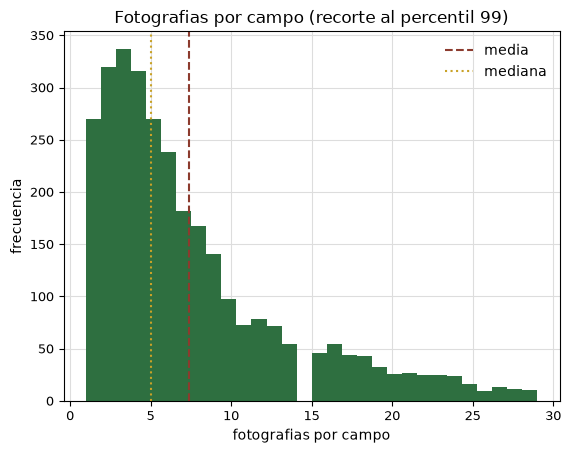

In [39]:
tope = fotos_por_campo.quantile(0.99)
_ = graficos.histograma(
    fotos_por_campo[fotos_por_campo <= tope], "Fotografias por campo (recorte al percentil 99)",
    "fotografias por campo", bins=30, nombre_archivo="02_histograma_fotos_por_campo",
)

In [40]:
rng = np.random.default_rng(42)
mezcla = rng.permutation(train.index.to_numpy())
corte = int(0.8 * len(mezcla))
indices_entrenamiento, indices_validacion = mezcla[:corte], mezcla[corte:]

campos_entrenamiento = set(train.loc[indices_entrenamiento, "id_campo"].dropna())
campos_validacion = set(train.loc[indices_validacion, "id_campo"].dropna())
campos_compartidos = campos_entrenamiento & campos_validacion
registros_afectados = train.loc[indices_validacion, "id_campo"].isin(campos_compartidos).mean()

print(f"campos presentes en ambos lados de la particion aleatoria: {len(campos_compartidos)}")
print(f"proporcion de registros de validacion en campos compartidos: {registros_afectados:.4f}")

campos presentes en ambos lados de la particion aleatoria: 1971
proporcion de registros de validacion en campos compartidos: 0.8792


Una particion aleatoria simple deja una fraccion alta de los registros de validacion en campos que
tambien aparecen en entrenamiento. Cualquier validacion honesta debe separar por campo, no al azar.

## Solapamiento de campos entre entrenamiento y prueba

Se verifica como esta construida la particion oficial de la competencia: cuantos campos y
productores aparecen en ambos conjuntos, y que proporcion de los registros de cada conjunto cae en
campos compartidos.

In [41]:
campos_train = set(train["id_campo"].dropna())
campos_test = set(test["id_campo"].dropna())
campos_comunes = campos_train & campos_test
productores_comunes = set(train["id_productor"].dropna()) & set(test["id_productor"].dropna())

print(f"campos en entrenamiento: {len(campos_train)}")
print(f"campos en prueba: {len(campos_test)}")
print(f"campos presentes en ambos: {len(campos_comunes)}")
print(f"productores presentes en ambos: {len(productores_comunes)}")
print(f"proporcion de registros de entrenamiento en campos compartidos: {train['id_campo'].isin(campos_comunes).mean():.4f}")
print(f"proporcion de registros de prueba en campos compartidos: {test['id_campo'].isin(campos_comunes).mean():.4f}")

campos en entrenamiento: 3051
campos en prueba: 2475
campos presentes en ambos: 2414
productores presentes en ambos: 212
proporcion de registros de entrenamiento en campos compartidos: 0.8065
proporcion de registros de prueba en campos compartidos: 0.8851


La particion oficial no separa los campos entre entrenamiento y prueba: 2414 de los 2475 campos de
prueba tambien aparecen en entrenamiento, y alrededor del 80 por ciento de los registros de
entrenamiento y del 88 por ciento de los de prueba caen en campos compartidos. Un modelo puede
aprender a reconocer el campo en lugar del dano, de modo que el desempeno reportado en una tabla de
posiciones basada en esta particion esta inflado por fuga de informacion y no mide generalizacion
real.

## Desplazamiento entre entrenamiento y prueba

Se comparan las distribuciones de temporada, etapa y tipo de dano entre entrenamiento y prueba con
la distancia de variacion total, y se grafica la composicion por temporada.

In [42]:
for variable in ("temporada", "etapa", "dano"):
    distancia = tablas.distancia_variacion_total(train, test, variable)
    print(f"distancia de variacion total en {variable}: {distancia:.4f}")

distancia de variacion total en temporada: 0.0088
distancia de variacion total en etapa: 0.0008
distancia de variacion total en dano: 0.0016


,train,test,diferencia
temporada,,,
SR2021,0.380812,0.372042,0.008770
LR2021,0.304780,0.308784,-0.004005
SR2020,0.236420,0.239294,-0.002873
LR2020,0.077988,0.079880,-0.001892


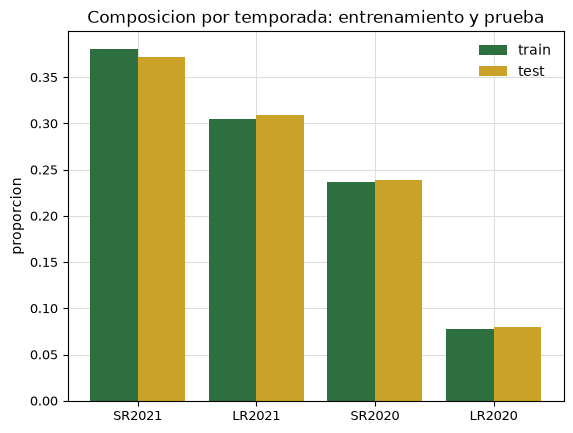

In [43]:
composicion_temporada = tablas.comparar_distribuciones_categoricas(train, test, "temporada").set_index("temporada")
display(composicion_temporada)
_ = graficos.barras_comparativas(
    composicion_temporada, ["train", "test"], "Composicion por temporada: entrenamiento y prueba",
    "proporcion", nombre_archivo="02_comparacion_temporada",
)

Las distribuciones de estas variables son casi identicas entre entrenamiento y prueba, con
distancias de variacion total por debajo de 0.01. Combinado con el fuerte solapamiento de campos
de la seccion anterior, esto indica que la particion oficial se construyo de forma aleatoria y
estratificada, sin separar por campo ni por temporada. Por lo tanto el desplazamiento que hace
fallar a los modelos entre temporadas no es visible al evaluar sobre esta particion oficial: hay
que buscarlo comparando temporadas directamente, tanto en las etiquetas como en las imagenes.

## Cierre de la etapa

El analisis tabular delimita el problema desde el lado de las etiquetas: la magnitud esta
condicionada al diagnostico de sequia, su severidad se desplaza entre temporadas, la particion
oficial no separa por campo ni expone el desplazamiento entre temporadas, y existe ruido de
etiquetado acotado. El cuaderno `03_eda_imagenes` incorpora los atributos visuales de las
fotografias para verificar si las diferencias entre temporadas tambien se manifiestan en las
condiciones de captura.